# 1 - Imports

In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[0].parents[0]))

In [154]:
from src.utils import config, io
from src.features import selection, pruning
from src.preprocessing import preprocess_pipeline
from src.models import model_pipeline, evaluate

In [ ]:
import mlflow
import numpy as np
import pandas as pd
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns

from missingno import matrix as msno_matrix
from missingno import heatmap as msno_heatmap

sns.set_theme(style="whitegrid", context="talk")

# 2 - Preprocessing

In [5]:
split_cfg = io.load_json(config.PROCESSED_DATA_DIR / 'splits/temporal_v1.json')
split_cfg

{'description': 'Forecasting split for future country risk prediction',
 'train_years': [1999, 2017],
 'val_years': [2018, 2020],
 'test_years': [2021, 2024]}

In [6]:
def temporal_split(X, y, config):
    train_mask = (
        (X['YEAR'] >= config['train_years'][0]) &
        (X['YEAR'] <= config['train_years'][1])
    )

    val_mask = (
        (X['YEAR'] >= config['val_years'][0]) &
        (X['YEAR'] <= config['val_years'][1])
    )

    test_mask = (
        (X['YEAR'] >= config['test_years'][0]) &
        (X['YEAR'] <= config['test_years'][1])
    )

    X_train, y_train = X[train_mask], y[train_mask]
    X_val, y_val     = X[val_mask], y[val_mask]
    X_test, y_test   = X[test_mask], y[test_mask]

    return X_train, y_train, X_val, y_val, X_test, y_test


In [ ]:
def expanding_window_split(df, start_year, end_year, val_start_year):

    for val_year in range(val_start_year, end_year + 1):
        
        train_mask = (df['YEAR'] >= start_year) & (df['YEAR'] < val_year)
        val_mask = df['YEAR'] == val_year
        
        train_idx = df.index[train_mask]
        val_idx = df.index[val_mask]
        
        if len(val_idx) > 0:
            yield train_idx, val_idx


In [47]:
!mlflow server --port 500

/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
[2026-02-13 16:16:09 +0100] [21506] [INFO] Starting gunicorn 23.0.0
[2026-02-13 16:16:09 +0100] [21506] [ERROR] connection to ('127.0.0.1', 500) failed: [Errno 13] Permission denied
[2026-02-13 16:16:10 +0100] [21506] [ERROR] connection to ('127.0.0.1', 500) failed: [Errno 13] Permission denied
[2026-02-13 16:16:11 +0100] [21506] [ERROR] connection to ('127.0.0.1', 500) failed: [Errno 13] Permission denied
[2026-02-13 16:16:12 +0100] [21506] [ERROR] connection to ('127.0.0.1', 500) failed: [Errno 13] Permission denied
[2026-02-13 16:16:13 +0100] [21506] [ERROR] connection to ('127.0.0.1', 500) failed: [Errno 13] Permission denied
[2026-02-13 16:16:14 +0100] [21506] [ERROR] Can't connect

# 3 - Parameter Tuning for Dataset

## 3.1 - Parameter Tuning Feature Selection

### 3.1.1 - Run Parameter Cross Validation

In [ ]:
mlflow.set_tracking_uri(config.PROJECT_ROOT / 'models/mlruns')
# mlflow.create_experiment('Feature Selection Parameters')
mlflow.set_experiment('Feature Selection Parameters')

<Experiment: artifact_location='file:///Users/hippolytegrandet/Desktop/Dev/country_risk_rating/models/mlruns/378044102522567349', creation_time=1770992451508, experiment_id='378044102522567349', last_update_time=1770992451508, lifecycle_stage='active', name='Feature Selection Parameters', tags={}>

In [41]:
dataset = io.load_csv(config.INTERIM_DATA_DIR / 'merged_dataset.csv', index_col=0)
dataset

,YEAR,ISO3_COUNTRY_CODE,OECD_RATING,GEO_REGION,ADMIN_REGION,LENDING_TYPE,INCOME_GROUP,NY.GDP.MKTP.CD,NY.GDP.MKTP.KD.ZG,NY.GDP.MKTP.PP.CD,...,SE.PRM.CUAT.ZS,SP.POP.DPND,SL.TLF.CACT.ZS,GE.EST,RQ.EST,IC.BRE.BI.OS,IC.BRE.BE.OS,IQ.CPA.PADM.XQ,FS.AST.PRVT.GD.ZS,FM.AST.PRVT.GD.ZS
COUNTRY_PERIOD_INDEX,,,,,,,,,,,,,,,,,,,,,
AFG-1999,1999,AFG,7,MEA,MNA,IDX,LIC,NaN,NaN,NaN,...,NaN,108.686031,46.609,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AFG-2000,2000,AFG,7,MEA,MNA,IDX,LIC,3.521418e+09,NaN,1.637703e+10,...,NaN,109.586048,46.562,-2.173946,-2.080253,NaN,NaN,NaN,NaN,NaN
AFG-2001,2001,AFG,-,MEA,MNA,IDX,LIC,2.813572e+09,-9.431974,1.516633e+10,...,NaN,110.219341,46.526,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AFG-2002,2002,AFG,-,MEA,MNA,IDX,LIC,3.825701e+09,28.600001,1.980700e+10,...,NaN,110.534611,46.505,-1.587687,-1.811546,NaN,NaN,NaN,NaN,NaN
AFG-2003,2003,AFG,-,MEA,MNA,IDX,LIC,4.520947e+09,8.832278,2.198200e+10,...,NaN,110.557540,46.497,-1.175768,-1.463108,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZWE-2019,2019,ZWE,7,SSF,SSA,IDB,LMC,3.335770e+10,-6.332450,6.361373e+10,...,75.001228,85.447906,65.795,-1.310435,-1.486515,NaN,NaN,3.0,3.428022,3.428022
ZWE-2020,2020,ZWE,7,SSF,SSA,IDB,LMC,3.198033e+10,-7.816951,6.488043e+10,...,NaN,84.384381,64.665,-1.342368,-1.434415,NaN,NaN,3.0,3.642132,3.642132
ZWE-2021,2021,ZWE,7,SSF,SSA,IDB,LMC,4.128767e+10,8.468017,7.625453e+10,...,NaN,83.384953,65.397,-1.290561,-1.386109,NaN,NaN,3.0,4.759522,4.759522


In [39]:
def get_dataset_feature_selected(dataset, params):
    non_float_features_t = list(dataset.columns[dataset.dtypes!=float])

    # print('Initial Dataset Shape:', dataset.shape)
    dataset = dataset[dataset['OECD_RATING'] != '-']
    # print('Drop Null Target Shape:', dataset.shape)
    dataset = selection.filter_missingness(
        dataset, 
        max_missing_ratio=params['max_missing_ratio']
    )
    # print('Filter Missingness Shape:', dataset.shape)
    dataset = selection.filter_low_variance(
        dataset, 
        threshold=params['low_var_threshold']
    )
    # print('Filter Low Variance Shape:', dataset.shape)
    dataset = selection.filter_correlated(
        dataset,
        max_corr=params['max_corr']
    )
    # print('Filter Correlated Shape:', dataset.shape)
    # dataset = selection.select_by_mutual_information(
    #     dataset.drop(columns=['OECD_RATING']),
    #     dataset['OECD_RATING'],
    #     top_k=params['top_k_mi']
    # )
    # print('Filter Mutual Information Shape:', dataset.shape)
    # print(params)
    print('Final Dataset Shape:', dataset.shape)
    return dataset

def get_X_y(dataset):
    # Drop Instances with little data
    dataset = dataset[(dataset.isna().sum(axis=1) / len(dataset.columns)) <= 0.5]

    non_float_features_t = list(dataset.columns[dataset.dtypes!=float])
    non_float_features = []
    for c in non_float_features_t:
        if c != 'OECD_RATING':
            non_float_features.append(c)

    X = dataset.drop(columns=['OECD_RATING']) # Drop Target
    X = X.drop(columns=['ISO3_COUNTRY_CODE']) # Drop Country ID (maybe YEAR)
    y = dataset['OECD_RATING']

    return X, y

def transform_initial_dataset(dataset, feature_selection_params):

    dataset = get_dataset_feature_selected(dataset, feature_selection_params)
    X, y = get_X_y(dataset)

    return X, y

In [42]:
feature_selection_grid = {
    'max_missing_ratio': [0.2, 0.3, 0.4, 0.5, 0.6],
    'low_var_threshold': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
    'max_corr': [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95],
    'top_k_mi': [25, 50, 100, 200]
}

In [43]:
preprocessor_params = {
    'num_imputer': {}, 
    'num_scaler': True, 
    'cat': {'cat_imputer': {}}
}

model_params = {
    'C': 1.0,
    'max_iter': 1000,
    'class_weight': 'balanced'
}

In [ ]:
for max_missing_ratio, low_var_threshold, max_corr, top_k_mi in product(
    feature_selection_grid['max_missing_ratio'], feature_selection_grid['low_var_threshold'], feature_selection_grid['max_corr'], feature_selection_grid['top_k_mi'], 
):

    selected_params = {
        'max_missing_ratio': max_missing_ratio, 
        'low_var_threshold': low_var_threshold, 
        'max_corr': max_corr, 
        'top_k_mi': top_k_mi
    }
    X, y = transform_initial_dataset(dataset, selected_params)
    preprocessor = preprocess_pipeline.build_preprocessor(X, params=preprocessor_params) # Get Default pipeline
    model = model_pipeline.get_model_pipeline('logistic_regression', preprocessor, model_params)

    cv_scores = {
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': []
    }
    with mlflow.start_run():

        for fold, (train_idx, val_idx) in enumerate(expanding_window_split(df=X, start_year=1999, end_year=2020, val_start_year=2015)):
            fold_prefix = 'fold_' + str(fold) + '_'

            X_train, y_train = X.loc[train_idx], y.loc[train_idx]
            X_val, y_val = X.loc[val_idx], y.loc[val_idx]
                        
            model.fit(X_train, y_train)

            val_fold_results = evaluate.evaluate_model(model, X_val, y_val, prefix=fold_prefix, verbose=False)

            cv_scores['accuracy'].append(val_fold_results[fold_prefix + 'accuracy'])
            cv_scores['precision'].append(val_fold_results[fold_prefix + 'precision'])
            cv_scores['recall'].append(val_fold_results[fold_prefix + 'recall'])
            cv_scores['f1'].append(val_fold_results[fold_prefix + 'f1'])

        mlflow.log_params(selected_params)
        print(selected_params)
        print(cv_scores)
        mlflow.log_metric('cv_mean_accuracy', np.mean(cv_scores['accuracy']))
        mlflow.log_metric('cv_mean_precision', np.mean(cv_scores['precision']))
        mlflow.log_metric('cv_mean_recall', np.mean(cv_scores['recall']))
        mlflow.log_metric('cv_mean_f1', np.mean(cv_scores['f1']))

Final Dataset Shape: (4204, 23)
{'max_missing_ratio': 0.2, 'low_var_threshold': 1e-05, 'max_corr': 0.5, 'top_k_mi': 25}
{'accuracy': [0.5672514619883041, 0.5470588235294118, 0.5433526011560693, 0.5491329479768786, 0.6140350877192983, 0.5789473684210527], 'precision': [0.5706649433201681, 0.5451571375484419, 0.4772680272680273, 0.49293899333075913, 0.5639998709256199, 0.5142093879572405], 'recall': [0.571072180213767, 0.53518222733339, 0.49346501349985666, 0.49546862439116657, 0.5283230834404133, 0.4906990894542321], 'f1': [0.5441783132583619, 0.5147249231100163, 0.4683167078848964, 0.4805314425010026, 0.5230983233784354, 0.4809699130554344]}
Final Dataset Shape: (4204, 23)
{'max_missing_ratio': 0.2, 'low_var_threshold': 1e-05, 'max_corr': 0.5, 'top_k_mi': 50}
{'accuracy': [0.5672514619883041, 0.5470588235294118, 0.5433526011560693, 0.5491329479768786, 0.6140350877192983, 0.5789473684210527], 'precision': [0.5706649433201681, 0.5451571375484419, 0.4772680272680273, 0.49293899333075913, 

### 3.1.2 - Analysis of Params Results

In [ ]:
e = mlflow.set_experiment('Feature Selection Parameters')
e.experiment_id

In [ ]:
client = mlflow.tracking.MlflowClient()
experiment_id = e.experiment_id

In [ ]:
feat_select_runs = client.search_runs(experiment_id)
len(feat_select_runs)

700

In [ ]:
rows = []
for run in feat_select_runs:
    run_dict = run.data.to_dictionary()

    row = {}
    for param, v in run_dict['params'].items():
        row[param] = v
    for metric, v in run_dict['metrics'].items():
        row[metric] = v

    rows.append(row)

In [ ]:
df = pd.DataFrame(rows)
df = df.astype(float)
df

,max_corr,low_var_threshold,max_missing_ratio,top_k_mi,cv_mean_precision,cv_mean_f1,cv_mean_accuracy,cv_mean_recall
0,0.95,0.10000,0.6,200.0,0.617672,0.605014,0.653633,0.617945
1,0.95,0.10000,0.6,100.0,0.617672,0.605014,0.653633,0.617945
2,0.95,0.10000,0.6,50.0,0.617672,0.605014,0.653633,0.617945
3,0.95,0.10000,0.6,25.0,0.617672,0.605014,0.653633,0.617945
4,0.90,0.10000,0.6,200.0,0.618328,0.603900,0.658791,0.616879
...,...,...,...,...,...,...,...,...
695,0.60,0.00001,0.2,25.0,0.519667,0.500709,0.570467,0.518946
696,0.50,0.00001,0.2,200.0,0.527373,0.501970,0.566630,0.519035
697,0.50,0.00001,0.2,100.0,0.527373,0.501970,0.566630,0.519035
698,0.50,0.00001,0.2,50.0,0.527373,0.501970,0.566630,0.519035


In [175]:
df.sort_values(by=['cv_mean_f1', 'cv_mean_accuracy'])

,max_corr,low_var_threshold,max_missing_ratio,top_k_mi,cv_mean_precision,cv_mean_f1,cv_mean_accuracy,cv_mean_recall
24,0.50,0.10000,0.6,200.0,0.507021,0.484968,0.568730,0.494998
25,0.50,0.10000,0.6,100.0,0.507021,0.484968,0.568730,0.494998
26,0.50,0.10000,0.6,50.0,0.507021,0.484968,0.568730,0.494998
27,0.50,0.10000,0.6,25.0,0.507021,0.484968,0.568730,0.494998
52,0.50,0.01000,0.6,200.0,0.507021,0.484968,0.568730,0.494998
...,...,...,...,...,...,...,...,...
95,0.85,0.00010,0.6,25.0,0.622142,0.612599,0.663399,0.630867
120,0.85,0.00001,0.6,200.0,0.622142,0.612599,0.663399,0.630867
121,0.85,0.00001,0.6,100.0,0.622142,0.612599,0.663399,0.630867
122,0.85,0.00001,0.6,50.0,0.622142,0.612599,0.663399,0.630867


#### Max Missing Missingness Ratio 

Text(0, 0.5, 'Mean F1 Score')

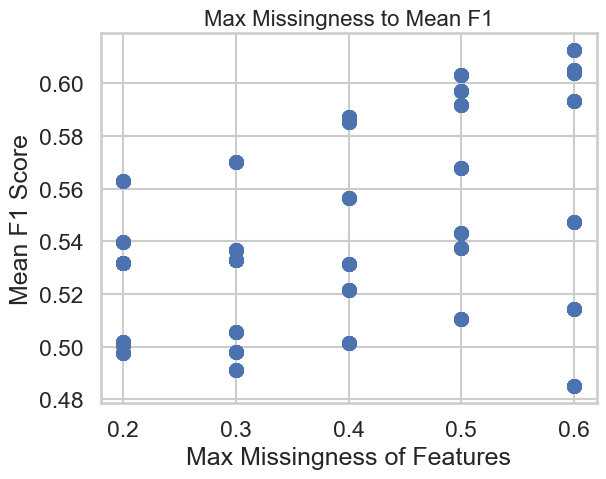

In [ ]:
plt.scatter(df['max_missing_ratio'], df['cv_mean_f1'])
plt.title('Max Missingness to Mean F1', fontsize=16)
plt.xlabel('Max Missingness of Features')
plt.ylabel('Mean F1 Score')

Text(0, 0.5, 'Mean Accuracy')

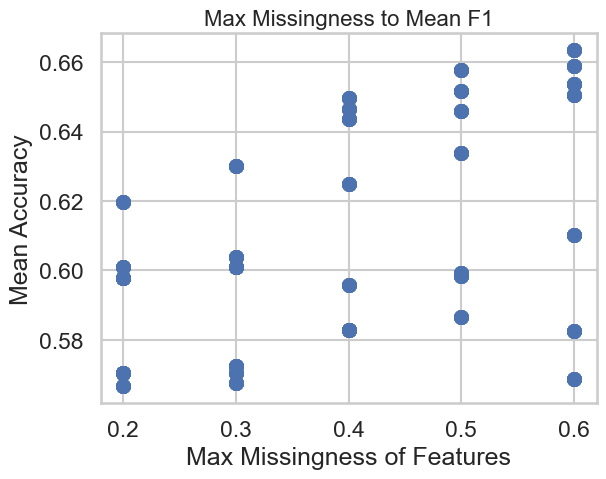

In [ ]:
plt.scatter(df['max_missing_ratio'], df['cv_mean_accuracy'])
plt.title('Max Missingness to Mean F1', fontsize=16)
plt.xlabel('Max Missingness of Features')
plt.ylabel('Mean Accuracy')

#### Low Variance Threshold

Text(0, 0.5, 'Mean F1 Score')

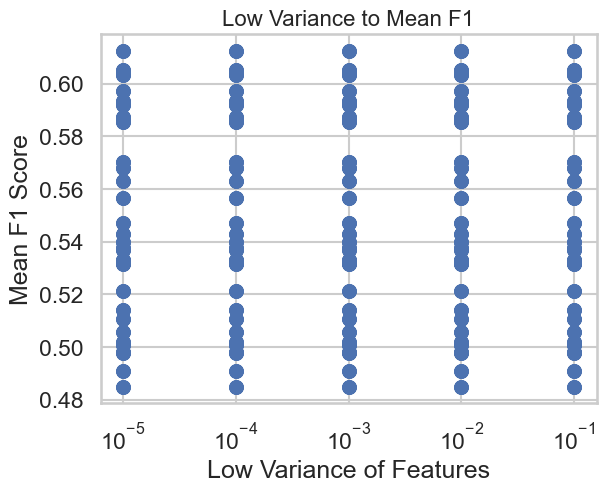

In [ ]:
fig = plt.figure()
ax = plt.gca()
ax.scatter(df['low_var_threshold'], df['cv_mean_f1'])
ax.set_xscale('log')
ax.set_title('Low Variance to Mean F1', fontsize=16)
ax.set_xlabel('Low Variance of Features')
ax.set_ylabel('Mean F1 Score')


Text(0, 0.5, 'Mean Accuracy')

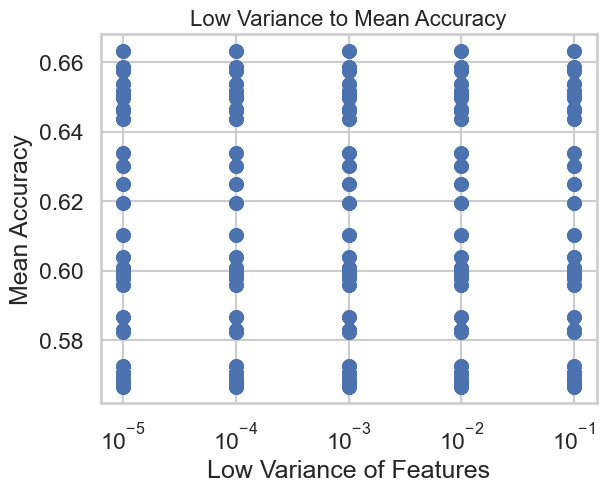

In [ ]:
fig = plt.figure()
ax = plt.gca()
ax.scatter(df['low_var_threshold'], df['cv_mean_accuracy'])
ax.set_xscale('log')
ax.set_title('Low Variance to Mean Accuracy', fontsize=16)
ax.set_xlabel('Low Variance of Features')
ax.set_ylabel('Mean Accuracy')


#### Max Correlation Parameter

Text(0, 0.5, 'Mean F1 Score')

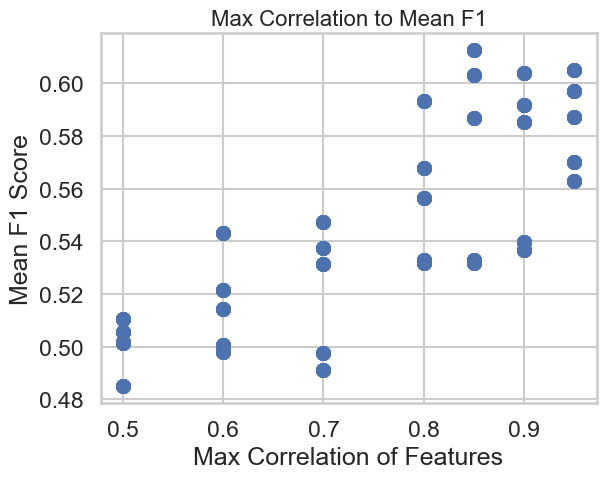

In [ ]:
plt.scatter(df['max_corr'], df['cv_mean_f1'])
plt.title('Max Correlation to Mean F1', fontsize=16)
plt.xlabel('Max Correlation of Features')
plt.ylabel('Mean F1 Score')

Text(0, 0.5, 'Mean Accuracy')

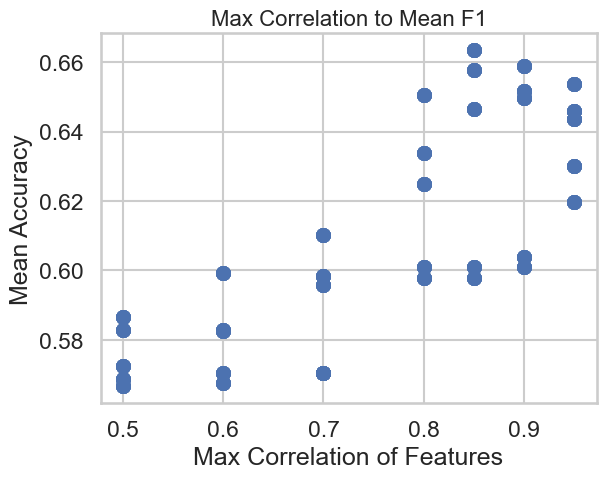

In [ ]:
plt.scatter(df['max_corr'], df['cv_mean_accuracy'])
plt.title('Max Correlation to Mean F1', fontsize=16)
plt.xlabel('Max Correlation of Features')
plt.ylabel('Mean Accuracy')

Best max_corr: 0.95

#### Set Subset For better View

In [ ]:
df_subset = df[df['max_corr'] == 0.95]
df_subset = df_subset.drop(columns=['top_k_mi', 'max_corr']).drop_duplicates()
df_subset

,low_var_threshold,max_missing_ratio,cv_mean_precision,cv_mean_f1,cv_mean_accuracy,cv_mean_recall
0,0.10000,0.6,0.617672,0.605014,0.653633,0.617945
28,0.01000,0.6,0.617672,0.605014,0.653633,0.617945
56,0.00100,0.6,0.617672,0.605014,0.653633,0.617945
84,0.00010,0.6,0.617672,0.605014,0.653633,0.617945
112,0.00001,0.6,0.617672,0.605014,0.653633,0.617945
140,0.10000,0.5,0.612374,0.597240,0.645896,0.610022
168,0.01000,0.5,0.612374,0.597240,0.645896,0.610022
196,0.00100,0.5,0.612374,0.597240,0.645896,0.610022
224,0.00010,0.5,0.612374,0.597240,0.645896,0.610022
252,0.00001,0.5,0.612374,0.597240,0.645896,0.610022


#### Max Missing Missingness Ratio 

Text(0, 0.5, 'Mean F1 Score')

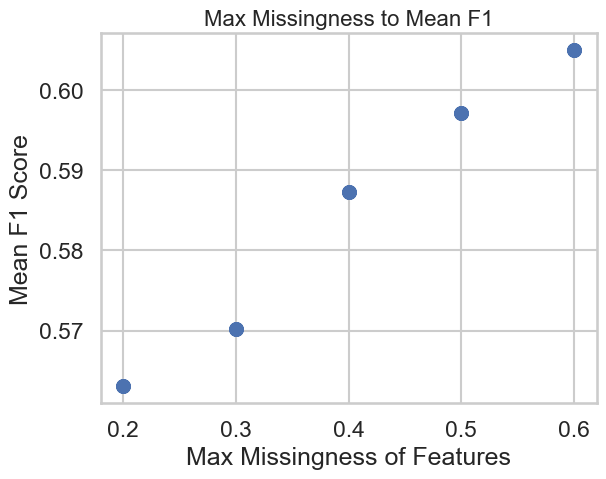

In [ ]:
plt.scatter(df_subset['max_missing_ratio'], df_subset['cv_mean_f1'])
plt.title('Max Missingness to Mean F1', fontsize=16)
plt.xlabel('Max Missingness of Features')
plt.ylabel('Mean F1 Score')

Text(0, 0.5, 'Mean Accuracy')

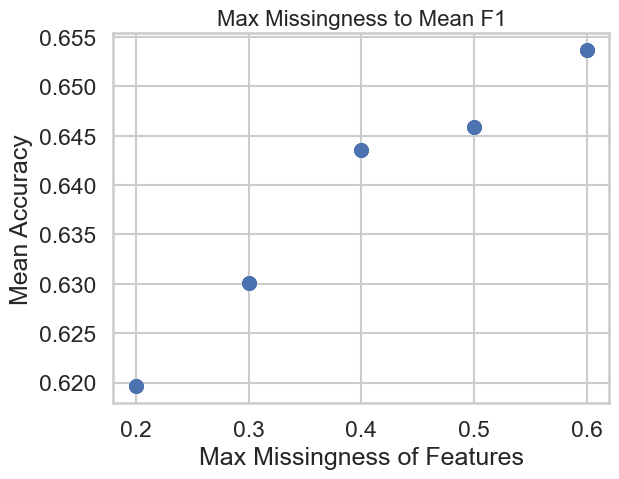

In [ ]:
plt.scatter(df_subset['max_missing_ratio'], df_subset['cv_mean_accuracy'])
plt.title('Max Missingness to Mean F1', fontsize=16)
plt.xlabel('Max Missingness of Features')
plt.ylabel('Mean Accuracy')

Best max_missing_ratio: 0.6

#### Low Variance Threshold

Text(0, 0.5, 'Mean F1 Score')

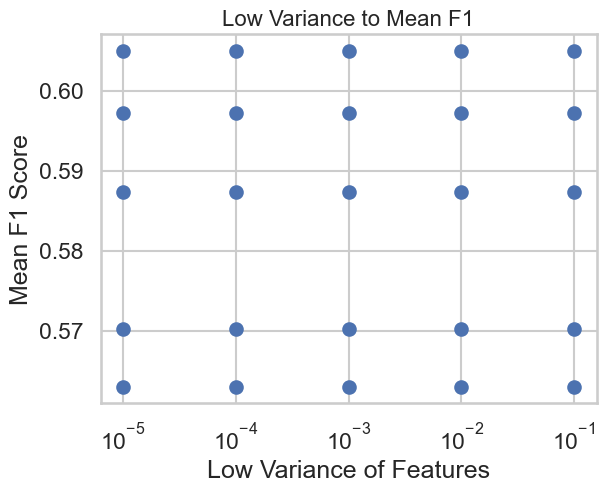

In [ ]:
fig = plt.figure()
ax = plt.gca()
ax.scatter(df_subset['low_var_threshold'], df_subset['cv_mean_f1'])
ax.set_xscale('log')
ax.set_title('Low Variance to Mean F1', fontsize=16)
ax.set_xlabel('Low Variance of Features')
ax.set_ylabel('Mean F1 Score')


Text(0, 0.5, 'Mean Accuracy')

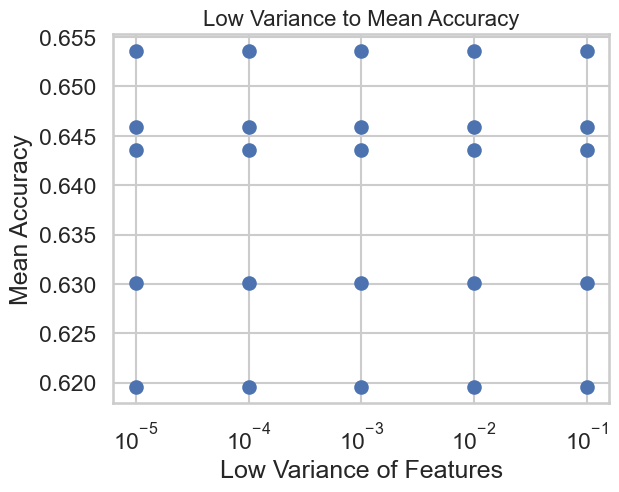

In [ ]:
fig = plt.figure()
ax = plt.gca()
ax.scatter(df_subset['low_var_threshold'], df_subset['cv_mean_accuracy'])
ax.set_xscale('log')
ax.set_title('Low Variance to Mean Accuracy', fontsize=16)
ax.set_xlabel('Low Variance of Features')
ax.set_ylabel('Mean Accuracy')


#### Correlation

In [ ]:
df.corr()

,max_corr,low_var_threshold,max_missing_ratio,top_k_mi,cv_mean_precision,cv_mean_f1,cv_mean_accuracy,cv_mean_recall
max_corr,1.000000e+00,1.187805e-17,-1.346650e-15,2.039939e-17,8.047031e-01,7.852137e-01,7.799878e-01,7.889775e-01
low_var_threshold,1.187805e-17,1.000000e+00,2.191037e-16,1.889756e-16,1.676826e-15,5.705914e-16,3.340624e-15,-2.126166e-15
max_missing_ratio,-1.346650e-15,2.191037e-16,1.000000e+00,6.200501e-16,4.286773e-01,4.620288e-01,4.843349e-01,4.382495e-01
top_k_mi,2.039939e-17,1.889756e-16,6.200501e-16,1.000000e+00,2.401401e-16,2.885995e-16,4.131479e-16,1.910585e-16
cv_mean_precision,8.047031e-01,1.676826e-15,4.286773e-01,2.401401e-16,1.000000e+00,9.944943e-01,9.842894e-01,9.905960e-01
cv_mean_f1,7.852137e-01,5.705914e-16,4.620288e-01,2.885995e-16,9.944943e-01,1.000000e+00,9.894790e-01,9.981645e-01
cv_mean_accuracy,7.799878e-01,3.340624e-15,4.843349e-01,4.131479e-16,9.842894e-01,9.894790e-01,1.000000e+00,9.849867e-01
cv_mean_recall,7.889775e-01,-2.126166e-15,4.382495e-01,1.910585e-16,9.905960e-01,9.981645e-01,9.849867e-01,1.000000e+00


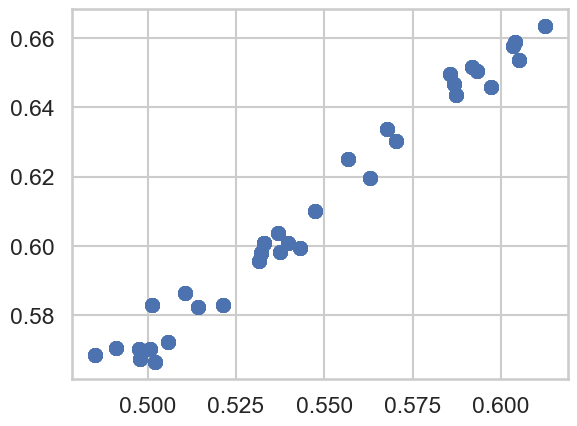

In [173]:
plt.scatter(df['cv_mean_f1'], df['cv_mean_accuracy'])

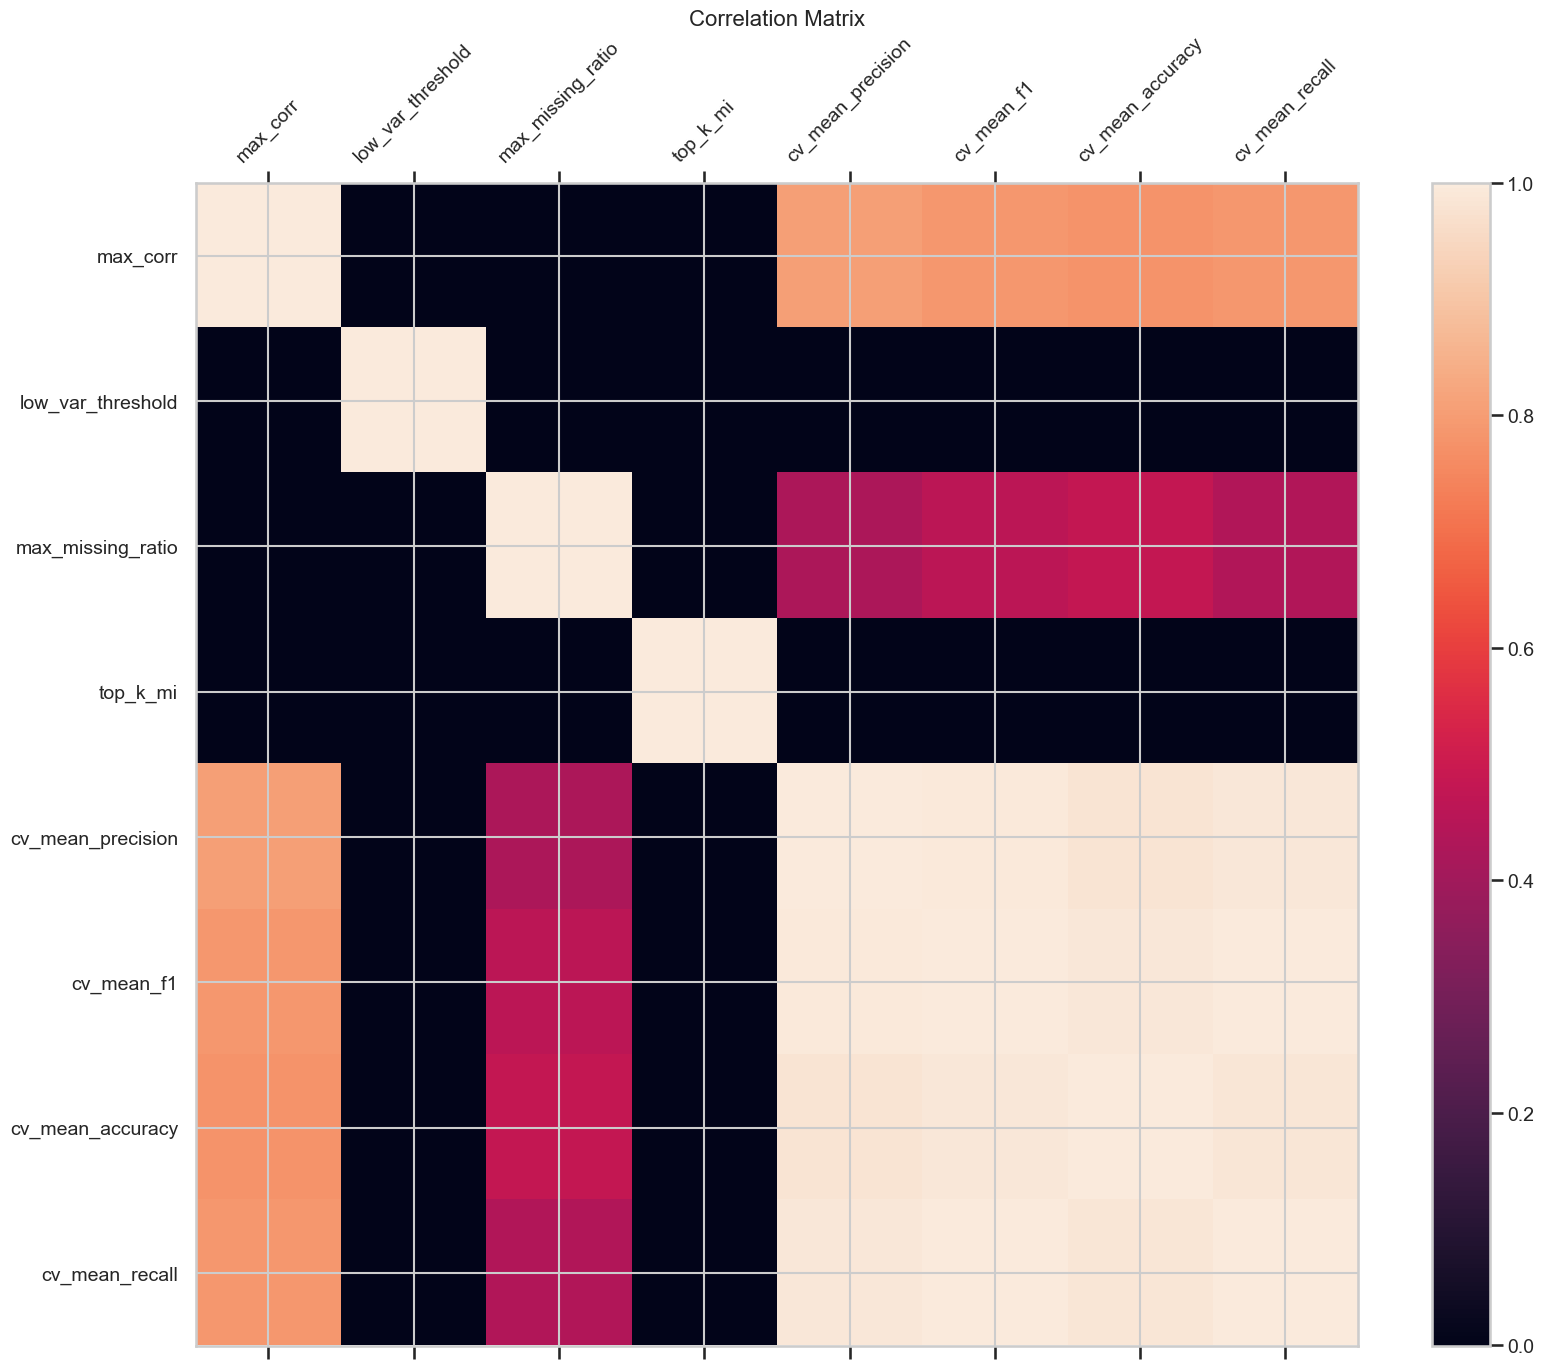

In [ ]:
# Source - https://stackoverflow.com/a/29432741
# Posted by jrjc, modified by community. See post 'Timeline' for change history
# Retrieved 2026-02-13, License - CC BY-SA 4.0

f = plt.figure(figsize=(19, 15))
plt.matshow(df.corr(), fignum=f.number)
plt.xticks(range(df.select_dtypes(['number']).shape[1]), df.select_dtypes(['number']).columns, fontsize=14, rotation=45)
plt.yticks(range(df.select_dtypes(['number']).shape[1]), df.select_dtypes(['number']).columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Correlation Matrix', fontsize=16);

In [ ]:
best_runs = client.search_runs(
    experiment_id, order_by=["metrics.cv_mean_accuracy DESC"], max_results=10
)

In [ ]:
best_runs[0]

<Run: data=<RunData: metrics={'cv_mean_accuracy': 0.6633988738462463,
 'cv_mean_f1': 0.6125989816725145,
 'cv_mean_precision': 0.622142271903296,
 'cv_mean_recall': 0.6308670713298491}, params={'low_var_threshold': '0.1',
 'max_corr': '0.85',
 'max_missing_ratio': '0.6',
 'top_k_mi': '200'}, tags={'mlflow.runName': 'logreg_expanding_cv',
 'mlflow.source.name': '/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/ipykernel_launcher.py',
 'mlflow.source.type': 'LOCAL',
 'mlflow.user': 'hippolytegrandet'}>, info=<RunInfo: artifact_uri='file:///Users/hippolytegrandet/Desktop/Dev/country_risk_rating/models/mlruns/378044102522567349/dd3bfe538f1245b28abfee1f33187d69/artifacts', end_time=1770993179401, experiment_id='378044102522567349', lifecycle_stage='active', run_id='dd3bfe538f1245b28abfee1f33187d69', run_name='logreg_expanding_cv', start_time=1770993178401, status='FINISHED', user_id='hippolytegrandet'>, inputs=<RunInputs: dataset_inputs=[], model_inp

In [ ]:
best_runs[9]

<Run: data=<RunData: metrics={'cv_mean_accuracy': 0.6633988738462463,
 'cv_mean_f1': 0.6125989816725145,
 'cv_mean_precision': 0.622142271903296,
 'cv_mean_recall': 0.6308670713298491}, params={'low_var_threshold': '0.001',
 'max_corr': '0.85',
 'max_missing_ratio': '0.6',
 'top_k_mi': '100'}, tags={'mlflow.runName': 'logreg_expanding_cv',
 'mlflow.source.name': '/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/ipykernel_launcher.py',
 'mlflow.source.type': 'LOCAL',
 'mlflow.user': 'hippolytegrandet'}>, info=<RunInfo: artifact_uri='file:///Users/hippolytegrandet/Desktop/Dev/country_risk_rating/models/mlruns/378044102522567349/a8f717ef13654f02ba82b82ada94d1af/artifacts', end_time=1770993106293, experiment_id='378044102522567349', lifecycle_stage='active', run_id='a8f717ef13654f02ba82b82ada94d1af', run_name='logreg_expanding_cv', start_time=1770993104855, status='FINISHED', user_id='hippolytegrandet'>, inputs=<RunInputs: dataset_inputs=[], model_i

## 3.2 - Parameter Tuning Preprocessor

### 3.2.1 - Run Parameters Cross Validation

In [195]:
mlflow.set_tracking_uri(config.PROJECT_ROOT / 'models/mlruns')
mlflow.create_experiment('Preprocessor Parameters')
mlflow.set_experiment('Preprocessor Parameters')

<Experiment: artifact_location='file:///Users/hippolytegrandet/Desktop/Dev/country_risk_rating/models/mlruns/466434138641885653', creation_time=1771010225544, experiment_id='466434138641885653', last_update_time=1771010225544, lifecycle_stage='active', name='Preprocessor Parameters', tags={}>

In [196]:
X = io.load_csv(config.PROCESSED_DATA_DIR / 'X.csv', index_col=0)
y = io.load_csv(config.PROCESSED_DATA_DIR / 'y.csv', index_col=0)

In [197]:
preprocessor_params_grid = {
    # Numeric Transformer
    # Numeric Imputation
    'num_imputer': {
        'knn': {
            'weights': ['uniform', 'distance'],
            'n_neighbors': [3, 5, 7, 11, 15]
        }, 'uni': {
            'strategy': ['mean', 'median', 'most_frequent', 'constant'],
            'fill_value': [0.0]
        }
    },
    # Scalarization
    'num_scaler': [True, False],

    # String Transformer
    'cat': {
        'uni': {
            'strategy': ['most_frequent', 'constant'],
            'fill_value': ['NaN']
        },
        '': {
            '1': [0],
            '2': [0]
        }
    }
}

In [203]:
model_params = {
    'max_iter': 1000,
    'class_weight': 'balanced'
}

In [204]:
for num_impute, num_scaler, cat_impute in product(
    preprocessor_params_grid['num_imputer'].keys(), preprocessor_params_grid['num_scaler'], preprocessor_params_grid['cat'].keys()
):
    if num_impute == 'knn':
        num_impute_param_1 = 'weights'
        num_impute_param_2 = 'n_neighbors'
    elif num_impute == 'uni':
        num_impute_param_1 = 'strategy'
        num_impute_param_2 = 'fill_value'

    for num_impute_1, num_impute_2 in product(
        preprocessor_params_grid['num_imputer'][num_impute][num_impute_param_1], preprocessor_params_grid['num_imputer'][num_impute][num_impute_param_2]
    ):
        if cat_impute == 'uni':
            cat_impute_param_1 = 'strategy'
            cat_impute_param_2 = 'fill_value'
        elif cat_impute == '':
            cat_impute_param_1 = '1'
            cat_impute_param_2 = '2'

        for cat_impute_1, cat_impute_2 in product(
            preprocessor_params_grid['cat'][cat_impute][cat_impute_param_1], preprocessor_params_grid['cat'][cat_impute][cat_impute_param_2]
        ):
            
            preprocessor_params = {
                'num_imputer': num_impute,
                'num_imputer' + '_' + num_impute + '_' + num_impute_param_1: num_impute_1,
                'num_imputer' + '_' + num_impute + '_' + num_impute_param_2: num_impute_2,
                'num_scaler': num_scaler,
                'cat_imputer': cat_impute,
                'cat_imputer' + '_' + cat_impute + '_' + cat_impute_param_1: cat_impute_1,
                'cat_imputer' + '_' + cat_impute + '_' + cat_impute_param_2: cat_impute_2,
            }
            # print(preprocessor_params)
            preprocessor = preprocess_pipeline.build_preprocessor(X, params=preprocessor_params)
            # print(model)

            with mlflow.start_run():

                for fold, (train_idx, val_idx) in enumerate(expanding_window_split(df=X, start_year=1999, end_year=2020, val_start_year=2015)):
                    fold_prefix = 'fold_' + str(fold) + '_'
                    
                    X_train, y_train = X.loc[train_idx], y.loc[train_idx, 'OECD_RATING']
                    X_val, y_val = X.loc[val_idx], y.loc[val_idx, 'OECD_RATING']
                    
                    model = model_pipeline.get_model_pipeline('logistic_regression', preprocessor, model_params)
                    model.fit(X_train, y_train)

                    val_fold_results = evaluate.evaluate_model(model, X_val, y_val, prefix=fold_prefix, verbose=False)

                    cv_scores['accuracy'].append(val_fold_results[fold_prefix + 'accuracy'])
                    cv_scores['precision'].append(val_fold_results[fold_prefix + 'precision'])
                    cv_scores['recall'].append(val_fold_results[fold_prefix + 'recall'])
                    cv_scores['f1'].append(val_fold_results[fold_prefix + 'f1'])

                mlflow.log_params(preprocessor_params)
                print(preprocessor_params)
                print(cv_scores)
                mlflow.log_metric('cv_mean_accuracy', np.mean(cv_scores['accuracy']))
                mlflow.log_metric('cv_mean_precision', np.mean(cv_scores['precision']))
                mlflow.log_metric('cv_mean_recall', np.mean(cv_scores['recall']))
                mlflow.log_metric('cv_mean_f1', np.mean(cv_scores['f1']))


{'num_imputer': 'knn', 'num_imputer_knn_weights': 'uniform', 'num_imputer_knn_n_neighbors': 3, 'num_scaler': True, 'cat_imputer': 'uni', 'cat_imputer_uni_strategy': 'most_frequent', 'cat_imputer_uni_fill_value': 'NaN'}
{'accuracy': [0.6190476190476191, 0.6024096385542169, 0.6745562130177515, 0.6863905325443787, 0.7090909090909091, 0.6303030303030303, 0.6130952380952381, 0.6265060240963856, 0.7159763313609467, 0.7159763313609467, 0.7151515151515152, 0.6727272727272727, 0.6309523809523809, 0.6506024096385542, 0.6863905325443787, 0.6982248520710059, 0.6787878787878788, 0.6666666666666666, 0.6309523809523809, 0.6445783132530121, 0.6863905325443787, 0.6863905325443787, 0.696969696969697, 0.6727272727272727, 0.6369047619047619, 0.6506024096385542, 0.6923076923076923, 0.6863905325443787, 0.703030303030303, 0.6606060606060606, 0.6309523809523809, 0.6566265060240963, 0.7041420118343196, 0.6923076923076923, 0.6909090909090909, 0.6606060606060606, 0.6190476190476191, 0.6204819277108434, 0.6923076

/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver option

{'num_imputer': 'knn', 'num_imputer_knn_weights': 'uniform', 'num_imputer_knn_n_neighbors': 3, 'num_scaler': False, 'cat_imputer': 'uni', 'cat_imputer_uni_strategy': 'most_frequent', 'cat_imputer_uni_fill_value': 'NaN'}
{'accuracy': [0.6190476190476191, 0.6024096385542169, 0.6745562130177515, 0.6863905325443787, 0.7090909090909091, 0.6303030303030303, 0.6130952380952381, 0.6265060240963856, 0.7159763313609467, 0.7159763313609467, 0.7151515151515152, 0.6727272727272727, 0.6309523809523809, 0.6506024096385542, 0.6863905325443787, 0.6982248520710059, 0.6787878787878788, 0.6666666666666666, 0.6309523809523809, 0.6445783132530121, 0.6863905325443787, 0.6863905325443787, 0.696969696969697, 0.6727272727272727, 0.6369047619047619, 0.6506024096385542, 0.6923076923076923, 0.6863905325443787, 0.703030303030303, 0.6606060606060606, 0.6309523809523809, 0.6566265060240963, 0.7041420118343196, 0.6923076923076923, 0.6909090909090909, 0.6606060606060606, 0.6190476190476191, 0.6204819277108434, 0.692307

/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver option

{'num_imputer': 'knn', 'num_imputer_knn_weights': 'uniform', 'num_imputer_knn_n_neighbors': 3, 'num_scaler': False, 'cat_imputer': 'uni', 'cat_imputer_uni_strategy': 'constant', 'cat_imputer_uni_fill_value': 'NaN'}
{'accuracy': [0.6190476190476191, 0.6024096385542169, 0.6745562130177515, 0.6863905325443787, 0.7090909090909091, 0.6303030303030303, 0.6130952380952381, 0.6265060240963856, 0.7159763313609467, 0.7159763313609467, 0.7151515151515152, 0.6727272727272727, 0.6309523809523809, 0.6506024096385542, 0.6863905325443787, 0.6982248520710059, 0.6787878787878788, 0.6666666666666666, 0.6309523809523809, 0.6445783132530121, 0.6863905325443787, 0.6863905325443787, 0.696969696969697, 0.6727272727272727, 0.6369047619047619, 0.6506024096385542, 0.6923076923076923, 0.6863905325443787, 0.703030303030303, 0.6606060606060606, 0.6309523809523809, 0.6566265060240963, 0.7041420118343196, 0.6923076923076923, 0.6909090909090909, 0.6606060606060606, 0.6190476190476191, 0.6204819277108434, 0.69230769230

...

{'num_imputer': 'knn', 'num_imputer_knn_weights': 'distance', 'num_imputer_knn_n_neighbors': 7, 'num_scaler': False, 'cat_imputer': 'uni', 'cat_imputer_uni_strategy': 'constant', 'cat_imputer_uni_fill_value': 'NaN'}
{'accuracy': [0.6190476190476191, 0.6024096385542169, 0.6745562130177515, 0.6863905325443787, 0.7090909090909091, 0.6303030303030303, 0.6130952380952381, 0.6265060240963856, 0.7159763313609467, 0.7159763313609467, 0.7151515151515152, 0.6727272727272727, 0.6309523809523809, 0.6506024096385542, 0.6863905325443787, 0.6982248520710059, 0.6787878787878788, 0.6666666666666666, 0.6309523809523809, 0.6445783132530121, 0.6863905325443787, 0.6863905325443787, 0.696969696969697, 0.6727272727272727, 0.6369047619047619, 0.6506024096385542, 0.6923076923076923, 0.6863905325443787, 0.703030303030303, 0.6606060606060606, 0.6309523809523809, 0.6566265060240963, 0.7041420118343196, 0.6923076923076923, 0.6909090909090909, 0.6606060606060606, 0.6190476190476191, 0.6204819277108434, 0.6923076923

/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver option

{'num_imputer': 'knn', 'num_imputer_knn_weights': 'distance', 'num_imputer_knn_n_neighbors': 11, 'num_scaler': False, 'cat_imputer': 'uni', 'cat_imputer_uni_strategy': 'most_frequent', 'cat_imputer_uni_fill_value': 'NaN'}
{'accuracy': [0.6190476190476191, 0.6024096385542169, 0.6745562130177515, 0.6863905325443787, 0.7090909090909091, 0.6303030303030303, 0.6130952380952381, 0.6265060240963856, 0.7159763313609467, 0.7159763313609467, 0.7151515151515152, 0.6727272727272727, 0.6309523809523809, 0.6506024096385542, 0.6863905325443787, 0.6982248520710059, 0.6787878787878788, 0.6666666666666666, 0.6309523809523809, 0.6445783132530121, 0.6863905325443787, 0.6863905325443787, 0.696969696969697, 0.6727272727272727, 0.6369047619047619, 0.6506024096385542, 0.6923076923076923, 0.6863905325443787, 0.703030303030303, 0.6606060606060606, 0.6309523809523809, 0.6566265060240963, 0.7041420118343196, 0.6923076923076923, 0.6909090909090909, 0.6606060606060606, 0.6190476190476191, 0.6204819277108434, 0.6923

/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver option

KeyboardInterrupt: 

# 3.2.2 - Analysis

In [176]:
e = mlflow.set_experiment('Preprocessor Parameters')
e.experiment_id

'899147910768443312'

In [177]:
client = mlflow.tracking.MlflowClient()
experiment_id = e.experiment_id

In [178]:
feat_select_runs = client.search_runs(experiment_id)
len(feat_select_runs)

66

In [179]:
rows = []
for run in feat_select_runs:
    run_dict = run.data.to_dictionary()

    row = {}
    for param, v in run_dict['params'].items():
        row[param] = v
    for metric, v in run_dict['metrics'].items():
        row[metric] = v

    rows.append(row)


In [181]:
df = pd.DataFrame(rows)
# df = df.astype(float)
df

,cat,num_scaler,num_imputer,cv_mean_precision,cv_mean_f1,cv_mean_accuracy,cv_mean_recall,max_corr,low_var_threshold,max_missing_ratio,top_k_mi
0,"{'': {'1': 0, '2': 0}}",False,"{'uni': {'strategy': 'constant', 'fill_value':...",0.490232,0.466744,0.511224,0.492603,NaN,NaN,NaN,NaN
1,"{'': {'1': 0, '2': 0}}",False,"{'uni': {'strategy': 'most_frequent', 'fill_va...",0.491966,0.468523,0.512999,0.493895,NaN,NaN,NaN,NaN
2,"{'': {'1': 0, '2': 0}}",False,"{'uni': {'strategy': 'median', 'fill_value': 0...",0.494052,0.470527,0.514858,0.495283,NaN,NaN,NaN,NaN
3,"{'': {'1': 0, '2': 0}}",False,"{'uni': {'strategy': 'mean', 'fill_value': 0.0}}",0.496711,0.473347,0.517909,0.497446,NaN,NaN,NaN,NaN
4,"{'cat_imputer': {'strategy': 'most_frequent', ...",False,"{'uni': {'strategy': 'constant', 'fill_value':...",0.498602,0.476407,0.521235,0.499709,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
61,NaN,NaN,NaN,0.625437,0.613517,0.668785,0.623233,0.95,0.1,0.6,200
62,NaN,NaN,NaN,0.622880,0.611945,0.668024,0.622293,0.95,0.1,0.6,200
63,NaN,NaN,NaN,0.621175,0.610652,0.667119,0.621489,0.95,0.1,0.6,200
64,NaN,NaN,NaN,0.621547,0.611148,0.666270,0.622572,0.95,0.1,0.6,200


In [117]:
feature_selection_grid

{'max_missing_ratio': [0.2, 0.3, 0.4, 0.5, 0.6],
 'low_var_threshold': [1e-05, 0.0001, 0.001, 0.01, 0.1],
 'max_corr': [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95],
 'top_k_mi': [25, 50, 100, 200]}

### Max Missing Missingness Ratio 

Text(0, 0.5, 'Mean F1 Score')

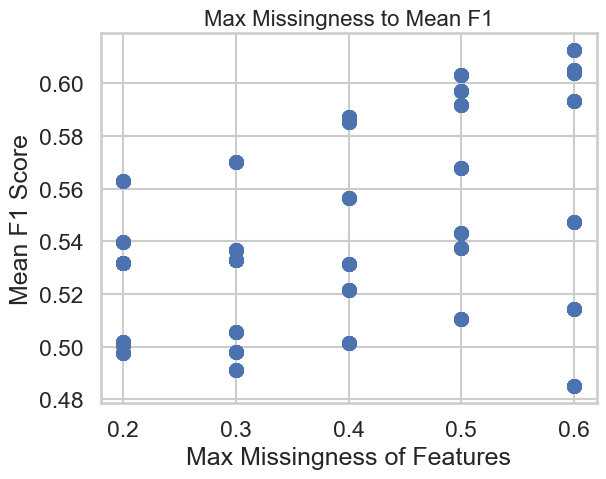

In [ ]:
plt.scatter(df['max_missing_ratio'], df['cv_mean_f1'])
plt.title('Max Missingness to Mean F1', fontsize=16)
plt.xlabel('Max Missingness of Features')
plt.ylabel('Mean F1 Score')

Text(0, 0.5, 'Mean Accuracy')

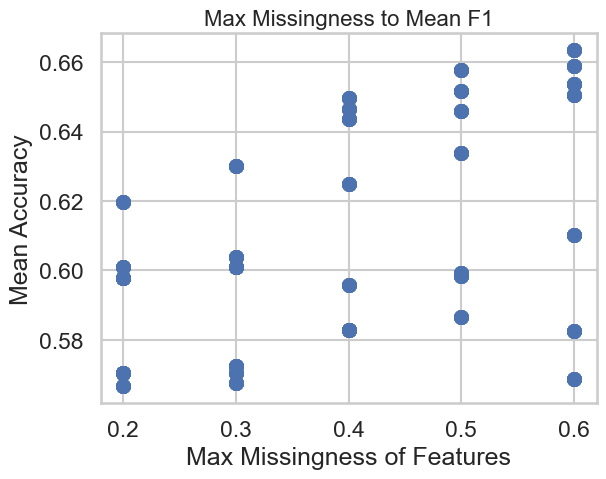

In [119]:
plt.scatter(df['max_missing_ratio'], df['cv_mean_accuracy'])
plt.title('Max Missingness to Mean F1', fontsize=16)
plt.xlabel('Max Missingness of Features')
plt.ylabel('Mean Accuracy')

### Low Variance Threshold

Text(0, 0.5, 'Mean F1 Score')

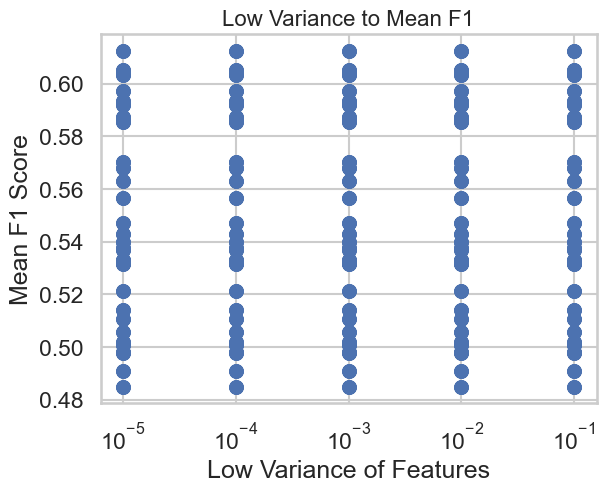

In [ ]:
fig = plt.figure()
ax = plt.gca()
ax.scatter(df['low_var_threshold'], df['cv_mean_f1'])
ax.set_xscale('log')
ax.set_title('Low Variance to Mean F1', fontsize=16)
ax.set_xlabel('Low Variance of Features')
ax.set_ylabel('Mean F1 Score')


Text(0, 0.5, 'Mean Accuracy')

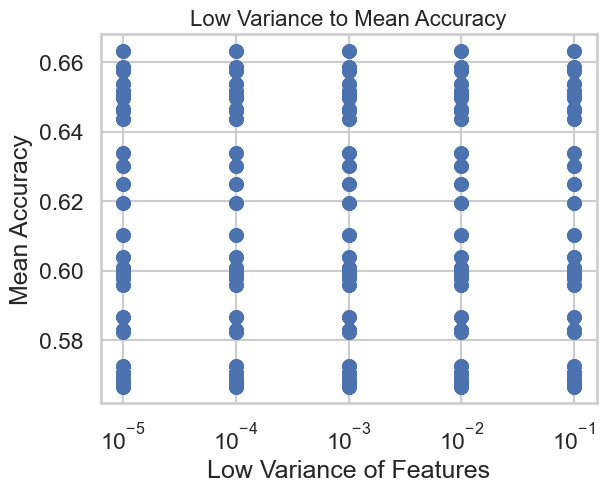

In [124]:
fig = plt.figure()
ax = plt.gca()
ax.scatter(df['low_var_threshold'], df['cv_mean_accuracy'])
ax.set_xscale('log')
ax.set_title('Low Variance to Mean Accuracy', fontsize=16)
ax.set_xlabel('Low Variance of Features')
ax.set_ylabel('Mean Accuracy')


### Max Correlation Parameter

Text(0, 0.5, 'Mean F1 Score')

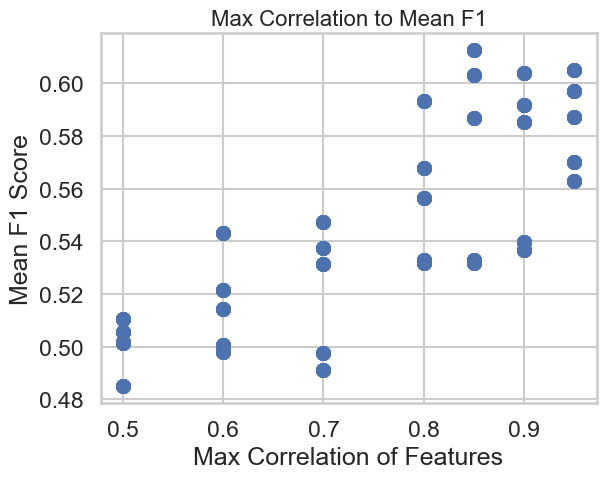

In [115]:
plt.scatter(df['max_corr'], df['cv_mean_f1'])
plt.title('Max Correlation to Mean F1', fontsize=16)
plt.xlabel('Max Correlation of Features')
plt.ylabel('Mean F1 Score')

Text(0, 0.5, 'Mean Accuracy')

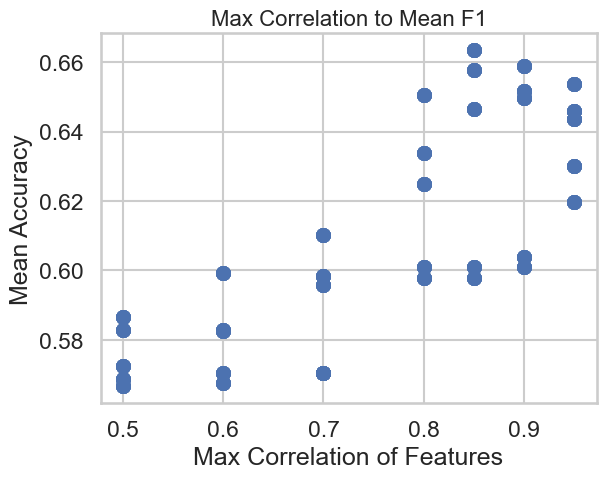

In [116]:
plt.scatter(df['max_corr'], df['cv_mean_accuracy'])
plt.title('Max Correlation to Mean F1', fontsize=16)
plt.xlabel('Max Correlation of Features')
plt.ylabel('Mean Accuracy')

Best max_corr: 0.95

### Set Subset For better View

In [128]:
df_subset = df[df['max_corr'] == 0.95]
df_subset = df_subset.drop(columns=['top_k_mi', 'max_corr']).drop_duplicates()
df_subset

,low_var_threshold,max_missing_ratio,cv_mean_precision,cv_mean_f1,cv_mean_accuracy,cv_mean_recall
0,0.10000,0.6,0.617672,0.605014,0.653633,0.617945
28,0.01000,0.6,0.617672,0.605014,0.653633,0.617945
56,0.00100,0.6,0.617672,0.605014,0.653633,0.617945
84,0.00010,0.6,0.617672,0.605014,0.653633,0.617945
112,0.00001,0.6,0.617672,0.605014,0.653633,0.617945
140,0.10000,0.5,0.612374,0.597240,0.645896,0.610022
168,0.01000,0.5,0.612374,0.597240,0.645896,0.610022
196,0.00100,0.5,0.612374,0.597240,0.645896,0.610022
224,0.00010,0.5,0.612374,0.597240,0.645896,0.610022
252,0.00001,0.5,0.612374,0.597240,0.645896,0.610022


### Max Missing Missingness Ratio 

Text(0, 0.5, 'Mean F1 Score')

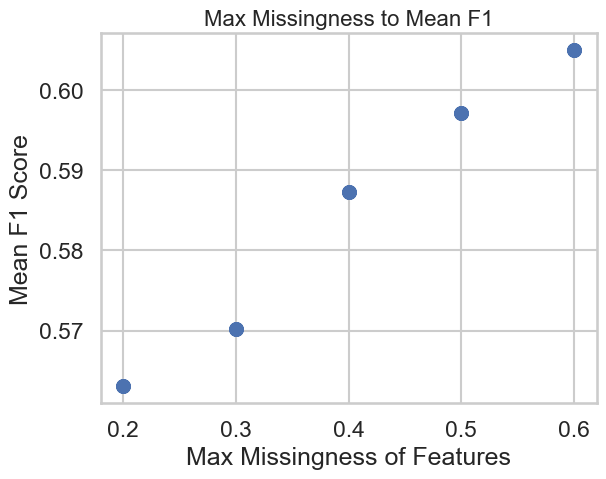

In [129]:
plt.scatter(df_subset['max_missing_ratio'], df_subset['cv_mean_f1'])
plt.title('Max Missingness to Mean F1', fontsize=16)
plt.xlabel('Max Missingness of Features')
plt.ylabel('Mean F1 Score')

Text(0, 0.5, 'Mean Accuracy')

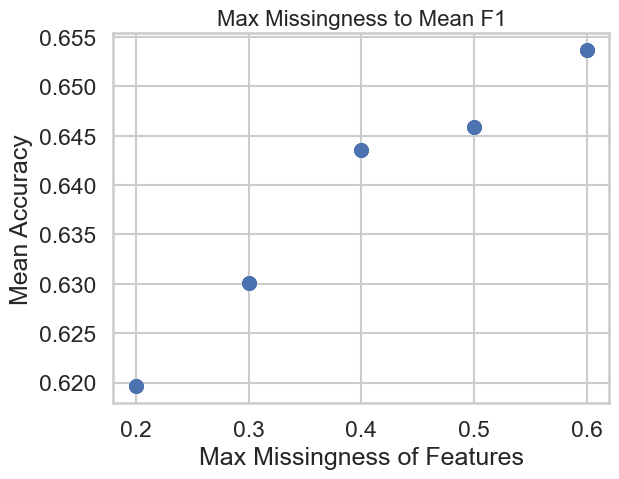

In [130]:
plt.scatter(df_subset['max_missing_ratio'], df_subset['cv_mean_accuracy'])
plt.title('Max Missingness to Mean F1', fontsize=16)
plt.xlabel('Max Missingness of Features')
plt.ylabel('Mean Accuracy')

Best max_missing_ratio: 0.6

### Low Variance Threshold

Text(0, 0.5, 'Mean F1 Score')

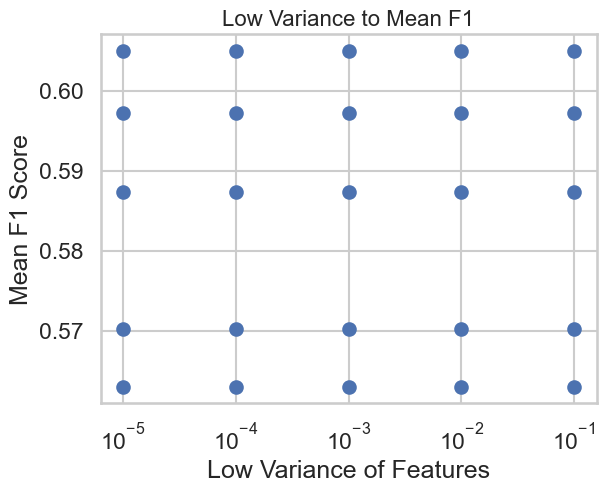

In [131]:
fig = plt.figure()
ax = plt.gca()
ax.scatter(df_subset['low_var_threshold'], df_subset['cv_mean_f1'])
ax.set_xscale('log')
ax.set_title('Low Variance to Mean F1', fontsize=16)
ax.set_xlabel('Low Variance of Features')
ax.set_ylabel('Mean F1 Score')


Text(0, 0.5, 'Mean Accuracy')

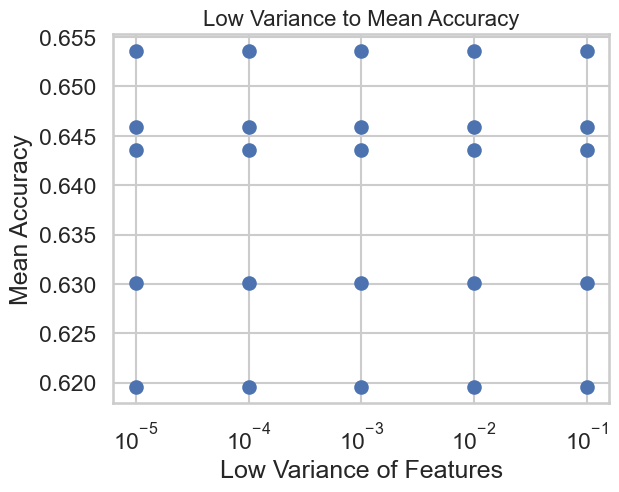

In [132]:
fig = plt.figure()
ax = plt.gca()
ax.scatter(df_subset['low_var_threshold'], df_subset['cv_mean_accuracy'])
ax.set_xscale('log')
ax.set_title('Low Variance to Mean Accuracy', fontsize=16)
ax.set_xlabel('Low Variance of Features')
ax.set_ylabel('Mean Accuracy')


### Max Correlation Parameter

### Correlation

In [104]:
df.corr()

,max_corr,low_var_threshold,max_missing_ratio,top_k_mi,cv_mean_precision,cv_mean_f1,cv_mean_accuracy,cv_mean_recall
max_corr,1.000000e+00,1.187805e-17,-1.346650e-15,2.039939e-17,8.047031e-01,7.852137e-01,7.799878e-01,7.889775e-01
low_var_threshold,1.187805e-17,1.000000e+00,2.191037e-16,1.889756e-16,1.676826e-15,5.705914e-16,3.340624e-15,-2.126166e-15
max_missing_ratio,-1.346650e-15,2.191037e-16,1.000000e+00,6.200501e-16,4.286773e-01,4.620288e-01,4.843349e-01,4.382495e-01
top_k_mi,2.039939e-17,1.889756e-16,6.200501e-16,1.000000e+00,2.401401e-16,2.885995e-16,4.131479e-16,1.910585e-16
cv_mean_precision,8.047031e-01,1.676826e-15,4.286773e-01,2.401401e-16,1.000000e+00,9.944943e-01,9.842894e-01,9.905960e-01
cv_mean_f1,7.852137e-01,5.705914e-16,4.620288e-01,2.885995e-16,9.944943e-01,1.000000e+00,9.894790e-01,9.981645e-01
cv_mean_accuracy,7.799878e-01,3.340624e-15,4.843349e-01,4.131479e-16,9.842894e-01,9.894790e-01,1.000000e+00,9.849867e-01
cv_mean_recall,7.889775e-01,-2.126166e-15,4.382495e-01,1.910585e-16,9.905960e-01,9.981645e-01,9.849867e-01,1.000000e+00


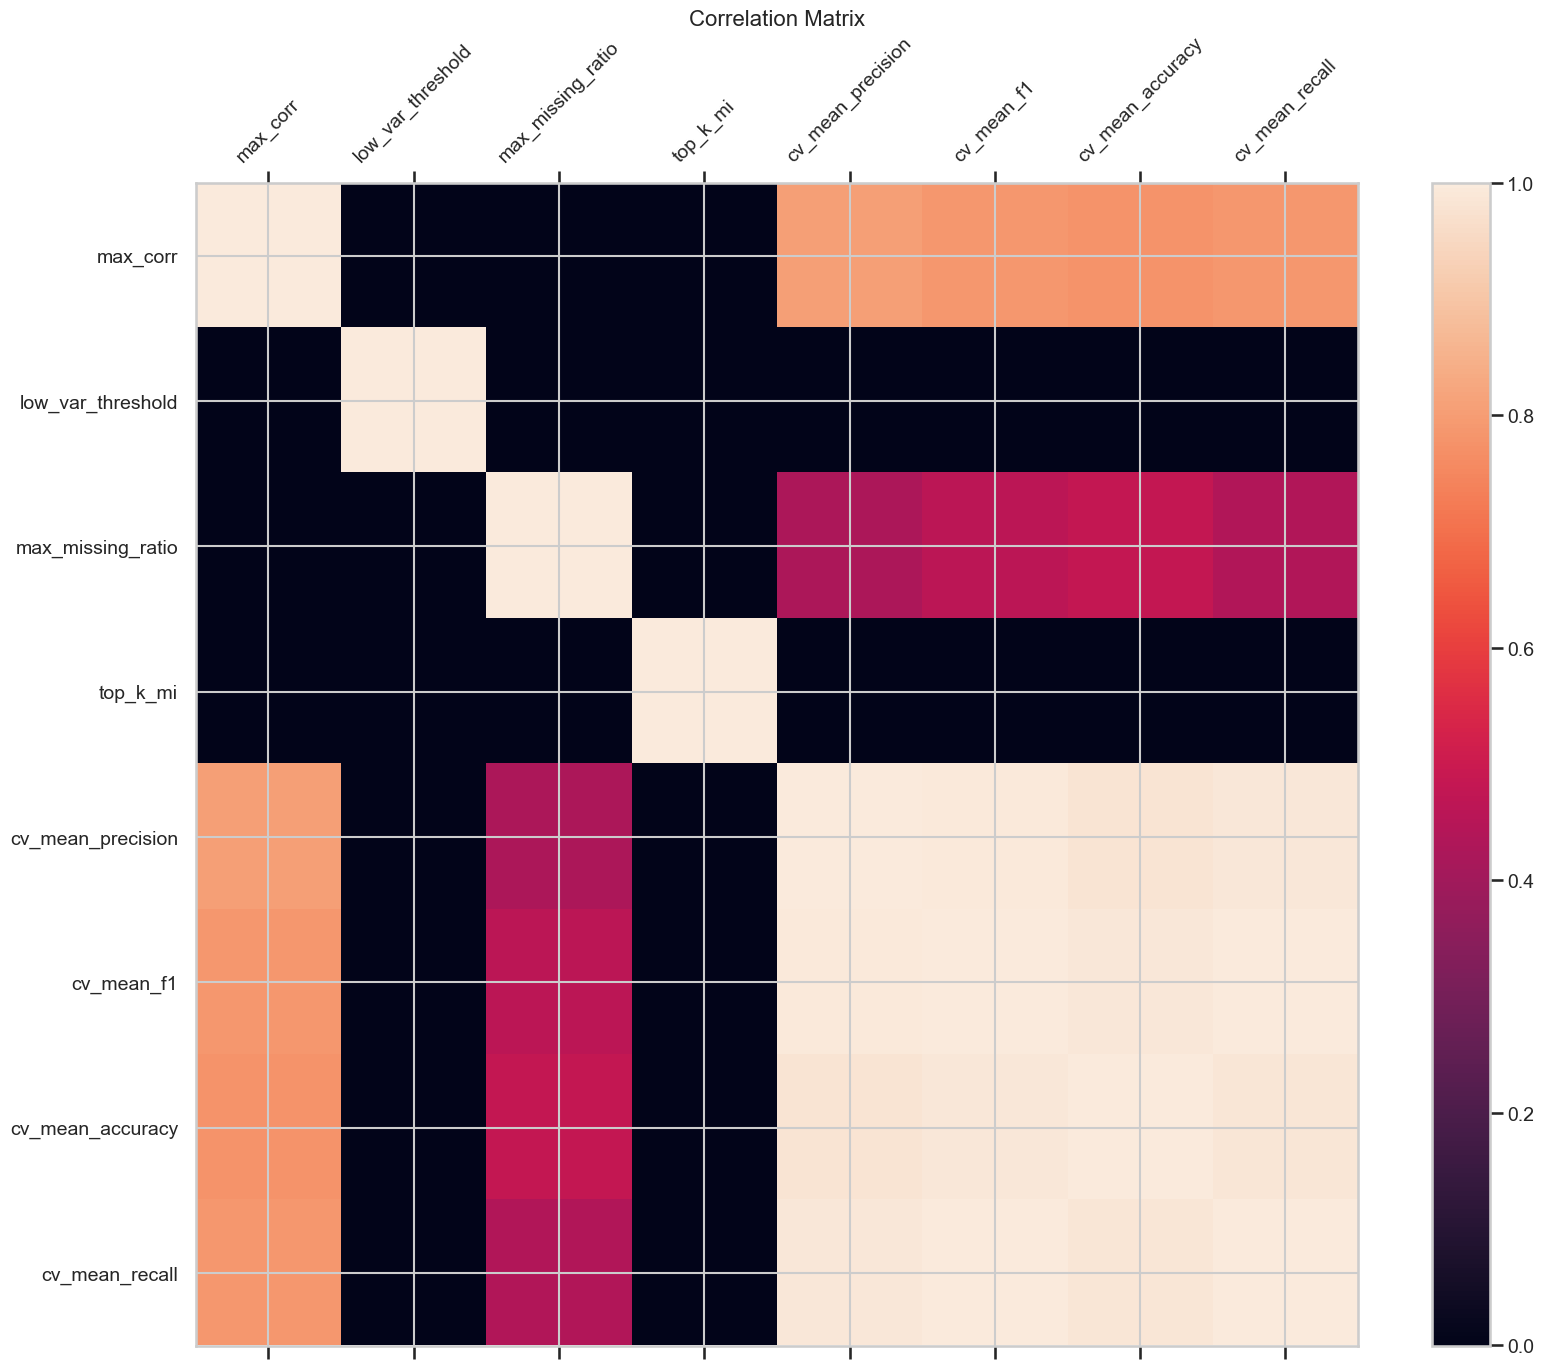

In [107]:
# Source - https://stackoverflow.com/a/29432741
# Posted by jrjc, modified by community. See post 'Timeline' for change history
# Retrieved 2026-02-13, License - CC BY-SA 4.0

f = plt.figure(figsize=(19, 15))
plt.matshow(df.corr(), fignum=f.number)
plt.xticks(range(df.select_dtypes(['number']).shape[1]), df.select_dtypes(['number']).columns, fontsize=14, rotation=45)
plt.yticks(range(df.select_dtypes(['number']).shape[1]), df.select_dtypes(['number']).columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Correlation Matrix', fontsize=16);

/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


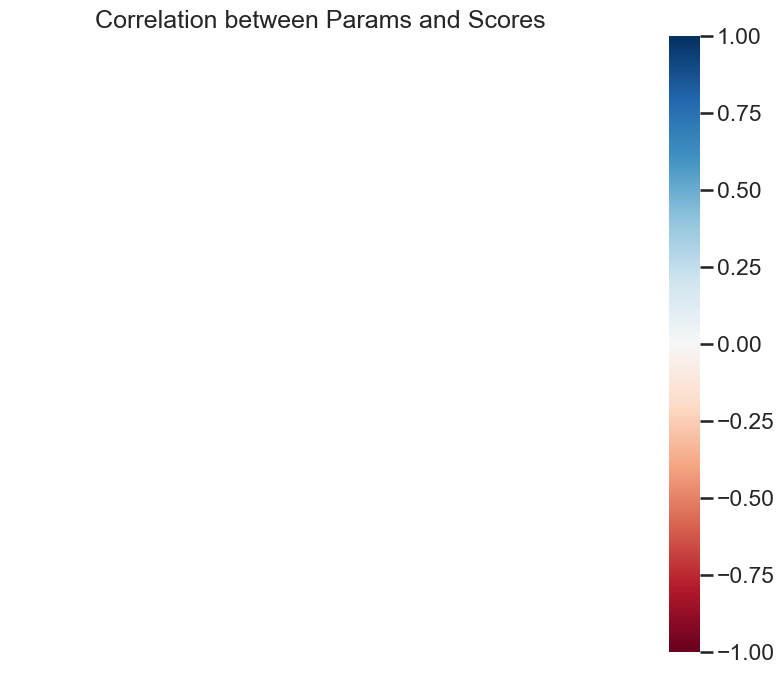

In [ ]:
msno_heatmap(df.corr(), figsize=(10, 8))
plt.title("Correlation between Params and Scores")
plt.show()

In [ ]:
best_runs = client.search_runs(
    experiment_id, order_by=["metrics.cv_mean_accuracy DESC"], max_results=10
)

In [62]:
best_runs[0]

<Run: data=<RunData: metrics={'cv_mean_accuracy': 0.6633988738462463,
 'cv_mean_f1': 0.6125989816725145,
 'cv_mean_precision': 0.622142271903296,
 'cv_mean_recall': 0.6308670713298491}, params={'low_var_threshold': '0.1',
 'max_corr': '0.85',
 'max_missing_ratio': '0.6',
 'top_k_mi': '200'}, tags={'mlflow.runName': 'logreg_expanding_cv',
 'mlflow.source.name': '/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/ipykernel_launcher.py',
 'mlflow.source.type': 'LOCAL',
 'mlflow.user': 'hippolytegrandet'}>, info=<RunInfo: artifact_uri='file:///Users/hippolytegrandet/Desktop/Dev/country_risk_rating/models/mlruns/378044102522567349/dd3bfe538f1245b28abfee1f33187d69/artifacts', end_time=1770993179401, experiment_id='378044102522567349', lifecycle_stage='active', run_id='dd3bfe538f1245b28abfee1f33187d69', run_name='logreg_expanding_cv', start_time=1770993178401, status='FINISHED', user_id='hippolytegrandet'>, inputs=<RunInputs: dataset_inputs=[], model_inp

In [64]:
best_runs[9]

<Run: data=<RunData: metrics={'cv_mean_accuracy': 0.6633988738462463,
 'cv_mean_f1': 0.6125989816725145,
 'cv_mean_precision': 0.622142271903296,
 'cv_mean_recall': 0.6308670713298491}, params={'low_var_threshold': '0.001',
 'max_corr': '0.85',
 'max_missing_ratio': '0.6',
 'top_k_mi': '100'}, tags={'mlflow.runName': 'logreg_expanding_cv',
 'mlflow.source.name': '/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/ipykernel_launcher.py',
 'mlflow.source.type': 'LOCAL',
 'mlflow.user': 'hippolytegrandet'}>, info=<RunInfo: artifact_uri='file:///Users/hippolytegrandet/Desktop/Dev/country_risk_rating/models/mlruns/378044102522567349/a8f717ef13654f02ba82b82ada94d1af/artifacts', end_time=1770993106293, experiment_id='378044102522567349', lifecycle_stage='active', run_id='a8f717ef13654f02ba82b82ada94d1af', run_name='logreg_expanding_cv', start_time=1770993104855, status='FINISHED', user_id='hippolytegrandet'>, inputs=<RunInputs: dataset_inputs=[], model_i

In [ ]:
!mlflow server --host 127.0.0.1 --port 8080